# AI-Based Stock Entry/Exit Decision Support System

**Course:** Data Science
**Instructor** Ma'am Fatima Yousaf

**Group Members**
1. Mashhood Farqaleet  - Roll No. 233807
2. Somal Atta Boloch
3. Fatima Khalid


## Step 1: Import Libraries

We import the libraries used in the whole project. Pandas and NumPy are used for data handling, Matplotlib and Seaborn for plotting, Scikit-learn for the classical machine learning models and the evaluation metrics, and TensorFlow Keras for the deep learning (CNN) models.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

tf.random.set_seed(42)
np.random.seed(42)

EDA_DIR = 'EDA_Visualizations'
os.makedirs(EDA_DIR, exist_ok=True)

print('Libraries imported successfully')

Libraries imported successfully


## Step 2: Data Collection

We use the yfinance library to download daily stock data straight from Yahoo Finance. We pick five well known technology companies and download about sixteen years of history for each one. Instead of placing every company in its own set of columns, we stack all of them on top of each other in a long format and add a Ticker column. This keeps the table tidy and gives us more than five thousand rows, which is the minimum the project requires.

In [2]:
!pip install yfinance -q
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']

if os.path.exists('stock_data_raw.csv'):
    df = pd.read_csv('stock_data_raw.csv')
else:
    frames = []
    for t in tickers:
        d = yf.download(t, start='2010-01-01', end='2026-01-01',
                        auto_adjust=True, progress=False)
        d = d.reset_index()
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = [c[0] for c in d.columns]
        d = d[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
        d['Ticker'] = t
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df.to_csv('stock_data_raw.csv', index=False)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print('Data downloaded successfully')
print('Shape:', df.shape)
df.head()


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Data downloaded successfully
Shape: (19998, 7)


,Date,Open,High,Low,Close,Volume,Ticker
0,2010-01-04,6.389118,6.421149,6.357686,6.406481,493729600,AAPL
1,2010-01-05,6.424143,6.453779,6.383730,6.417557,601904800,AAPL
2,2010-01-06,6.417557,6.443002,6.308891,6.315477,552160000,AAPL
3,2010-01-07,6.338825,6.346309,6.257999,6.303800,477131200,AAPL
4,2010-01-08,6.295419,6.346309,6.258300,6.345710,447610800,AAPL


## Step 3: Dataset Overview



In [3]:
print('Shape of dataset:', df.shape)
print('\nColumns:', list(df.columns))
print('\nData types:')
print(df.dtypes)
print('\nRows per company:')
print(df['Ticker'].value_counts())
print('\nStatistical summary:')
display(df.describe())
df.info()

Shape of dataset: (19998, 7)

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker']

Data types:
Date      datetime64[us]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
Ticker               str
dtype: object

Rows per company:
Ticker
AAPL    4024
AMZN    4024
GOOG    4024
MSFT    4024
TSLA    3902
Name: count, dtype: int64

Statistical summary:


,Date,Open,High,Low,Close,Volume
count,19998,19998.000000,19998.000000,19998.000000,19998.000000,1.999800e+04
mean,2018-01-16 19:27:31.485148,95.218073,96.420956,93.974708,95.236171,9.662859e+07
min,2010-01-04 00:00:00,1.076000,1.108667,0.998667,1.053333,1.584340e+05
25%,2014-01-29 00:00:00,18.691625,18.902225,18.500531,18.689053,3.156602e+07
50%,2018-01-18 00:00:00,46.067336,46.471646,45.748153,46.104668,6.019790e+07
75%,2022-01-05 18:00:00,150.226458,152.192182,148.140771,150.021370,1.054114e+08
max,2025-12-31 00:00:00,550.830186,551.048474,537.366763,538.658569,1.880998e+09
std,NaN,104.422238,105.771380,102.983635,104.412778,1.255640e+08


<class 'pandas.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    19998 non-null  datetime64[us]
 1   Open    19998 non-null  float64       
 2   High    19998 non-null  float64       
 3   Low     19998 non-null  float64       
 4   Close   19998 non-null  float64       
 5   Volume  19998 non-null  int64         
 6   Ticker  19998 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 1.1 MB


## Step 4: Handling Missing Values



In [4]:
print('Missing values before cleaning:')
print(df.isnull().sum())

df = df.sort_values(['Ticker', 'Date'])
price_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[price_cols] = df.groupby('Ticker')[price_cols].ffill()
df[price_cols] = df.groupby('Ticker')[price_cols].bfill()
df = df.reset_index(drop=True)

print('\nMissing values after cleaning:')
print(df.isnull().sum())

Missing values before cleaning:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
dtype: int64

Missing values after cleaning:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
dtype: int64


## Step 5: Removing Duplicate Records



In [5]:
print('Duplicate rows before:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Duplicate rows after:', df.duplicated().sum())

Duplicate rows before:

 0
Duplicate rows after: 0


## Step 6: Feature Engineering


In [6]:
def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

g = df.groupby('Ticker', group_keys=False)

df['MA10'] = g['Close'].transform(lambda s: s.rolling(10).mean())
df['MA20'] = g['Close'].transform(lambda s: s.rolling(20).mean())
df['MA50'] = g['Close'].transform(lambda s: s.rolling(50).mean())
df['Return'] = g['Close'].transform(lambda s: s.pct_change())
df['Volatility'] = g['Return'].transform(lambda s: s.rolling(10).std())
df['RSI'] = g['Close'].transform(lambda s: rsi(s))
df['Momentum'] = g['Close'].transform(lambda s: s - s.shift(10))
df['Range'] = df['High'] - df['Low']
df['VolumeChange'] = g['Volume'].transform(lambda s: s.pct_change())

df['NextClose'] = g['Close'].transform(lambda s: s.shift(-1))
df['Target'] = (df['NextClose'] > df['Close']).astype(int)

df = df.dropna().reset_index(drop=True)

print('Shape after feature engineering:', df.shape)
df[['Date', 'Ticker', 'Close', 'MA10', 'RSI', 'Return', 'Target']].head()

Shape after feature engineering: (19748, 18)


,Date,Ticker,Close,MA10,RSI,Return,Target
0,2010-03-16,AAPL,6.719004,6.604713,90.199215,0.002725,0
1,2010-03-17,AAPL,6.709128,6.648988,88.698482,-0.001470,1
2,2010-03-18,AAPL,6.724994,6.690718,87.806799,0.002365,0
3,2010-03-19,AAPL,6.653147,6.700596,77.039065,-0.010684,1
4,2010-03-22,AAPL,6.727986,6.717569,79.575918,0.011249,1


## Step 7: Outlier Detection and Handling


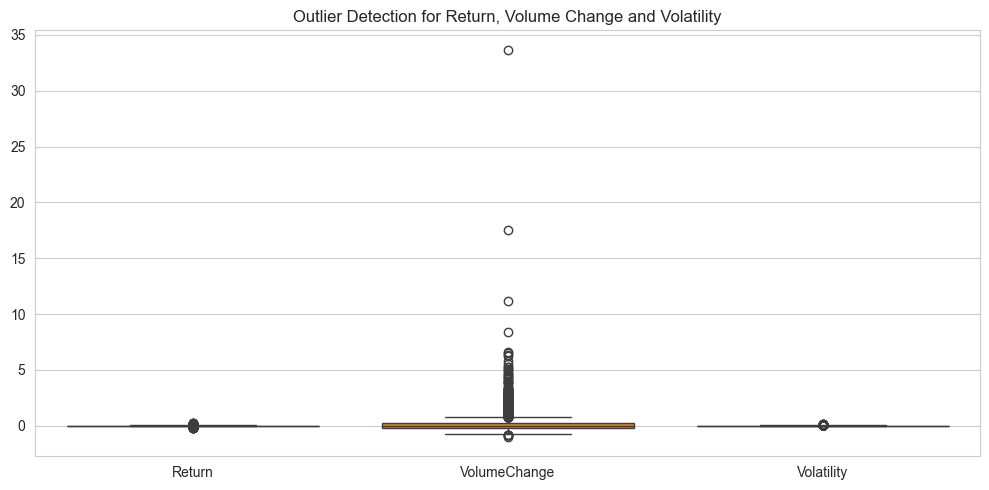

Outliers capped at 1st and 99th percentile for Return and VolumeChange


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[['Return', 'VolumeChange', 'Volatility']], ax=ax)
ax.set_title('Outlier Detection for Return, Volume Change and Volatility')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '07_outliers_before.png'), dpi=120)
plt.show()

for col in ['Return', 'VolumeChange']:
    low = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    df[col] = df[col].clip(low, high)

print('Outliers capped at 1st and 99th percentile for Return and VolumeChange')

## Step 8: Encoding the Company Column



In [8]:
le = LabelEncoder()
df['TickerCode'] = le.fit_transform(df['Ticker'])

ticker_dummies = pd.get_dummies(df['Ticker'], prefix='is')
df = pd.concat([df, ticker_dummies], axis=1)

print('Company encoding done')
print('One hot columns added:', list(ticker_dummies.columns))
df[['Ticker', 'TickerCode'] + list(ticker_dummies.columns)].head()

Company encoding done
One hot columns added: ['is_AAPL', 'is_AMZN', 'is_GOOG', 'is_MSFT', 'is_TSLA']


,Ticker,TickerCode,is_AAPL,is_AMZN,is_GOOG,is_MSFT,is_TSLA
0,AAPL,0,True,False,False,False,False
1,AAPL,0,True,False,False,False,False
2,AAPL,0,True,False,False,False,False
3,AAPL,0,True,False,False,False,False
4,AAPL,0,True,False,False,False,False


## Step 9: Exploratory Data Analysis



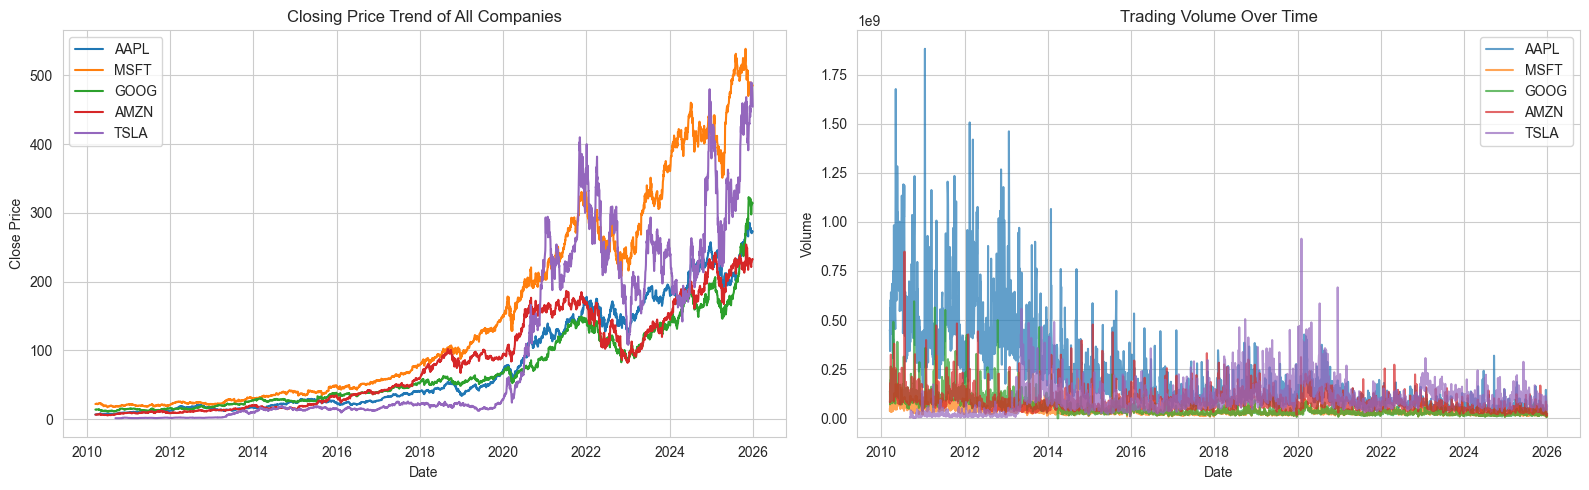

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for t in tickers:
    sub = df[df['Ticker'] == t]
    axes[0].plot(sub['Date'], sub['Close'], label=t)
axes[0].set_title('Closing Price Trend of All Companies')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Close Price')
axes[0].legend()

for t in tickers:
    sub = df[df['Ticker'] == t]
    axes[1].plot(sub['Date'], sub['Volume'], label=t, alpha=0.7)
axes[1].set_title('Trading Volume Over Time')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Volume')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '01_price_and_volume.png'), dpi=120)
plt.show()

**Insight:** The closing prices show a clear upward trend over the years for most companies, with sharp dips during market wide events. Trading volume is not constant and rises strongly during periods of big price movement, which tells us volume and volatility are linked.

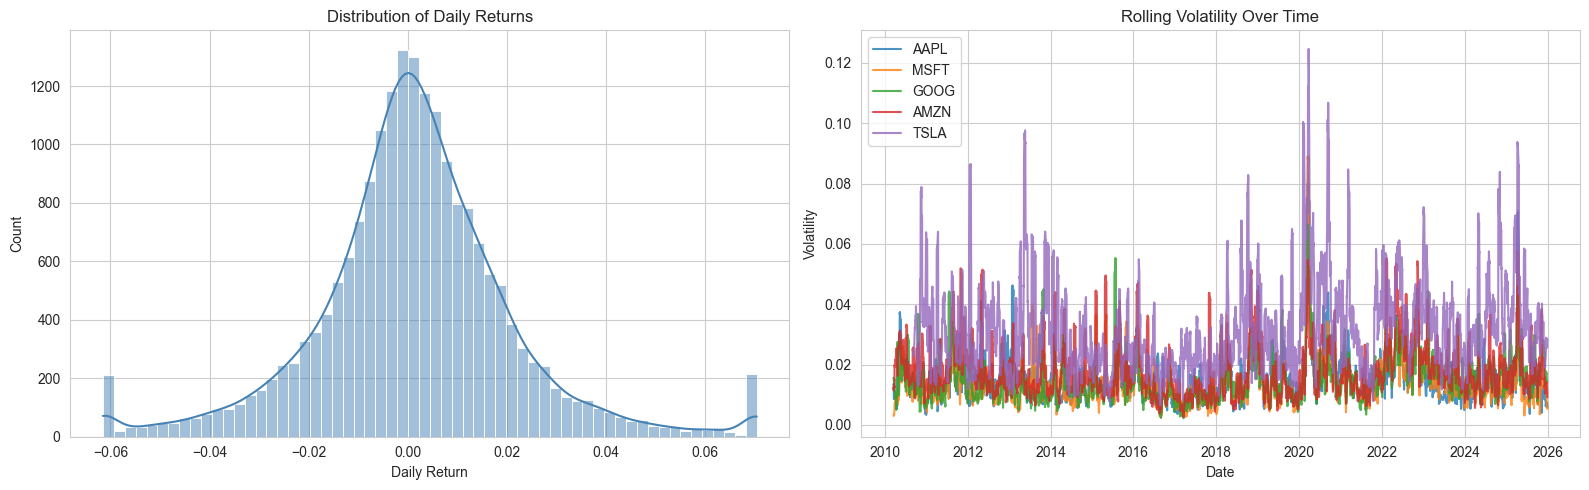

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['Return'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Daily Returns')
axes[0].set_xlabel('Daily Return')

for t in tickers:
    sub = df[df['Ticker'] == t]
    axes[1].plot(sub['Date'], sub['Volatility'], label=t, alpha=0.8)
axes[1].set_title('Rolling Volatility Over Time')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Volatility')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '02_returns_volatility.png'), dpi=120)
plt.show()

**Insight:** The daily returns are centred close to zero and look almost like a bell shape, which is normal for stock data. The volatility chart shows that risk is not steady. It spikes in certain periods, meaning some times are far more risky to trade than others.

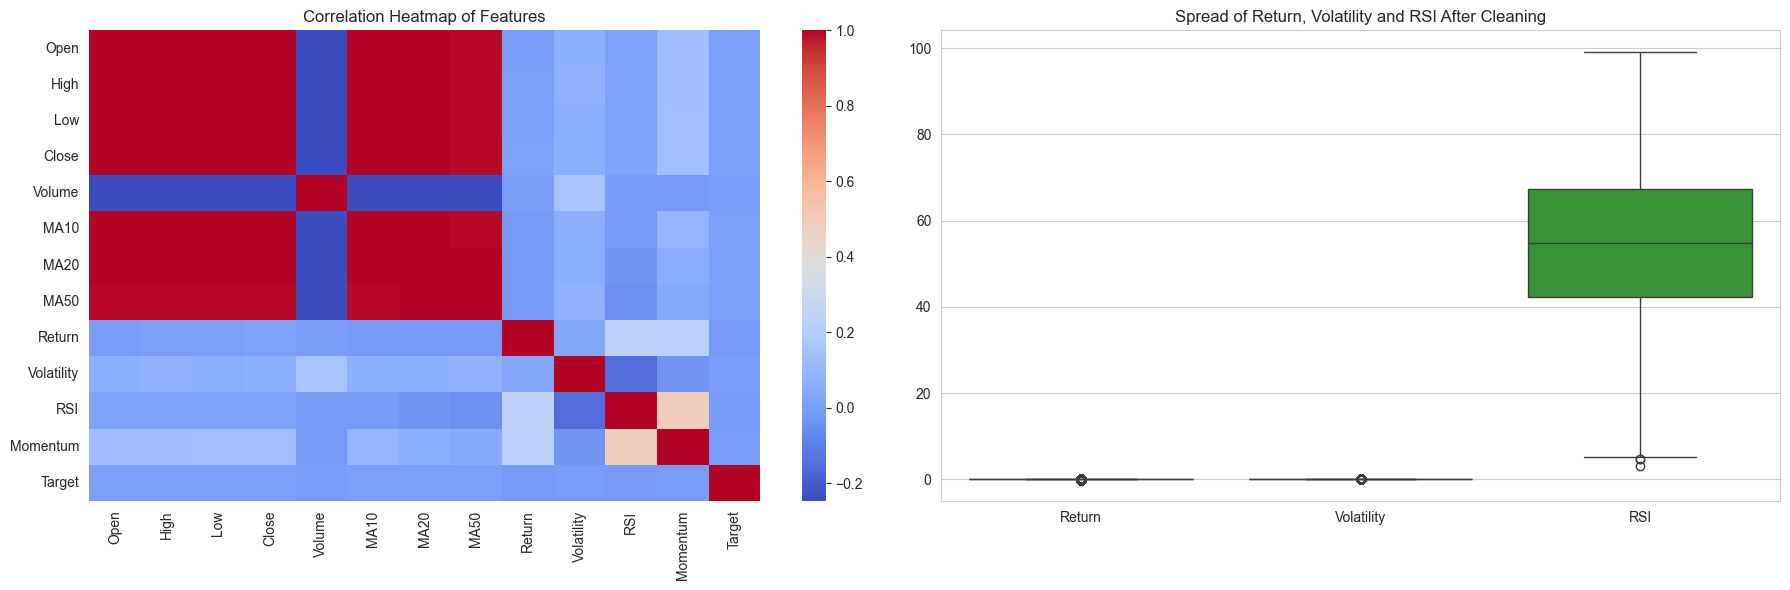

In [11]:
feature_cols_eda = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA10', 'MA20',
                    'MA50', 'Return', 'Volatility', 'RSI', 'Momentum', 'Target']
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(df[feature_cols_eda].corr(), annot=False, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation Heatmap of Features')

sns.boxplot(data=df[['Return', 'Volatility', 'RSI']], ax=axes[1])
axes[1].set_title('Spread of Return, Volatility and RSI After Cleaning')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '03_correlation_boxplot.png'), dpi=120)
plt.show()

**Insight:** The price based columns such as Open, High, Low, Close and the moving averages are highly correlated with each other because they all describe the same price level. The target has only a weak correlation with single features, which is expected and explains why next day direction is hard to predict and why we need stronger models.

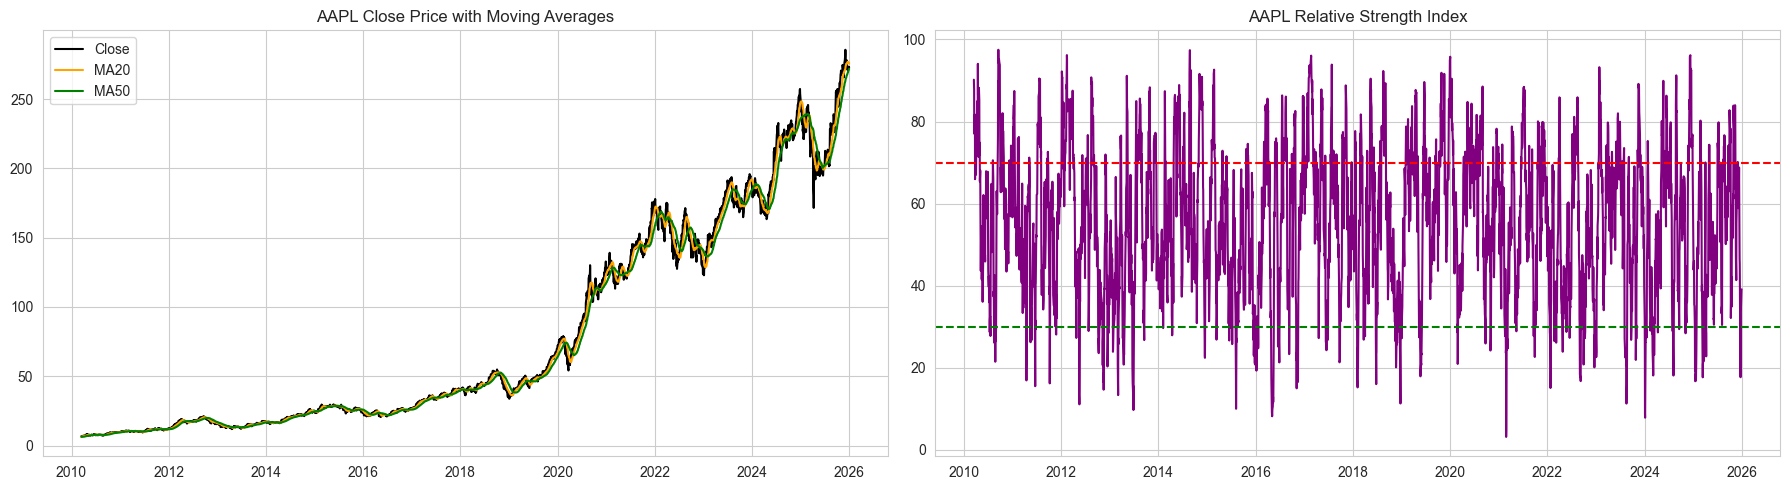

In [12]:
aapl = df[df['Ticker'] == 'AAPL']
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(aapl['Date'], aapl['Close'], label='Close', color='black')
axes[0].plot(aapl['Date'], aapl['MA20'], label='MA20', color='orange')
axes[0].plot(aapl['Date'], aapl['MA50'], label='MA50', color='green')
axes[0].set_title('AAPL Close Price with Moving Averages')
axes[0].legend()

axes[1].plot(aapl['Date'], aapl['RSI'], color='purple')
axes[1].axhline(70, color='red', linestyle='--')
axes[1].axhline(30, color='green', linestyle='--')
axes[1].set_title('AAPL Relative Strength Index')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '04_movingavg_rsi.png'), dpi=120)
plt.show()

**Insight:** The moving averages smooth out the noisy price line and make the long term trend easy to see. When the price stays above the moving averages the trend is upward. The RSI mostly stays between the 30 and 70 lines, and the times it crosses them mark moments where the stock was oversold or overbought.

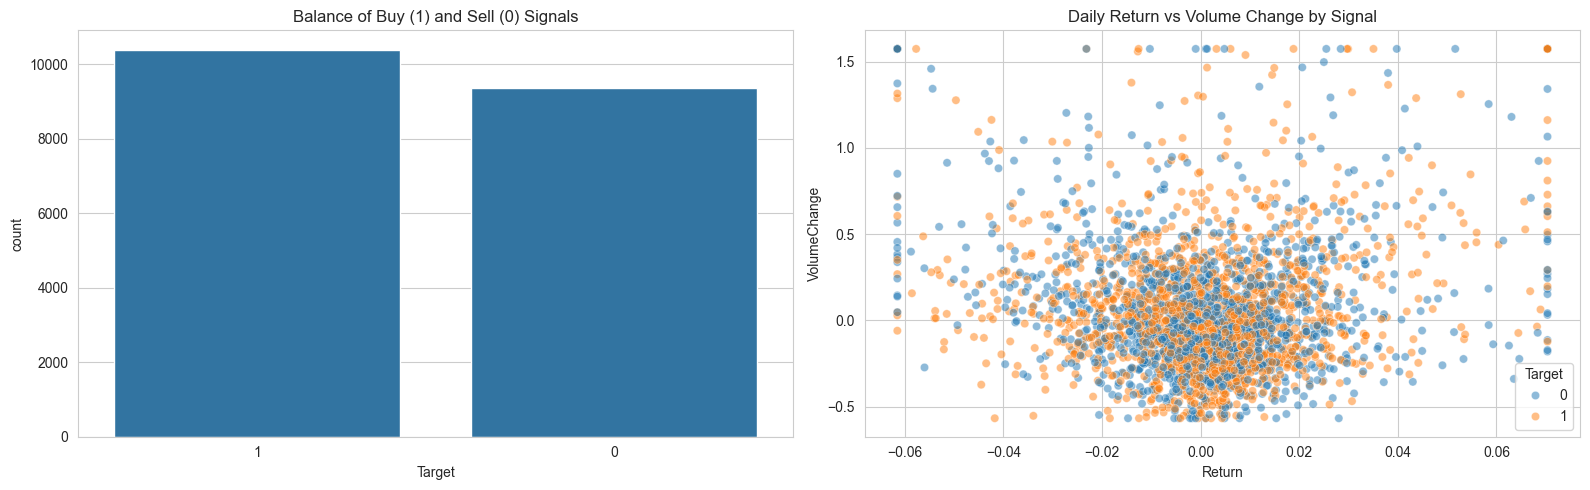

Target balance:
Target
1    0.526
0    0.474
Name: proportion, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
order = df['Target'].value_counts().index
sns.countplot(x='Target', data=df, ax=axes[0], order=order)
axes[0].set_title('Balance of Buy (1) and Sell (0) Signals')
axes[0].set_xlabel('Target')

sample = df.sample(3000, random_state=42)
sns.scatterplot(x='Return', y='VolumeChange', hue='Target',
                data=sample, alpha=0.5, ax=axes[1])
axes[1].set_title('Daily Return vs Volume Change by Signal')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '05_classbalance_scatter.png'), dpi=120)
plt.show()

print('Target balance:')
print(df['Target'].value_counts(normalize=True).round(3))

**Insight:** The Buy and Sell classes are almost balanced, which is good because the model will not be biased towards one side. The scatter plot shows that up and down days overlap a lot, so no single pair of features can separate them cleanly. This again shows why we use several features together inside the models.

## Step 10: Feature Selection, Scaling and Train Test Split


In [14]:
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA10', 'MA20', 'MA50',
                'Return', 'Volatility', 'RSI', 'Momentum', 'Range', 'VolumeChange',
                'TickerCode'] + list(ticker_dummies.columns)

df = df.sort_values('Date').reset_index(drop=True)

X = df[feature_cols].astype(float)
y = df['Target']

split_index = int(len(df) * 0.8)
X_train_raw, X_test_raw = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print('Training samples:', X_train.shape)
print('Testing samples:', X_test.shape)
print('Number of features:', len(feature_cols))

Training samples: (15798, 20)
Testing samples: (3950, 20)
Number of features: 20


## Step 11: Model 1 - Logistic Regression (Baseline)


In [15]:
results = []

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, pred_lr),
    'Precision': precision_score(y_test, pred_lr),
    'Recall': recall_score(y_test, pred_lr),
    'F1 Score': f1_score(y_test, pred_lr)
})

print('Logistic Regression trained')
print(classification_report(y_test, pred_lr))

Logistic Regression trained
              precision    recall  f1-score   support

           0       0.46      0.08      0.13      1840
           1       0.53      0.92      0.68      2110

    accuracy                           0.53      3950
   macro avg       0.50      0.50      0.40      3950
weighted avg       0.50      0.53      0.42      3950



## Step 12: Model 2 - Random Forest (Ensemble)



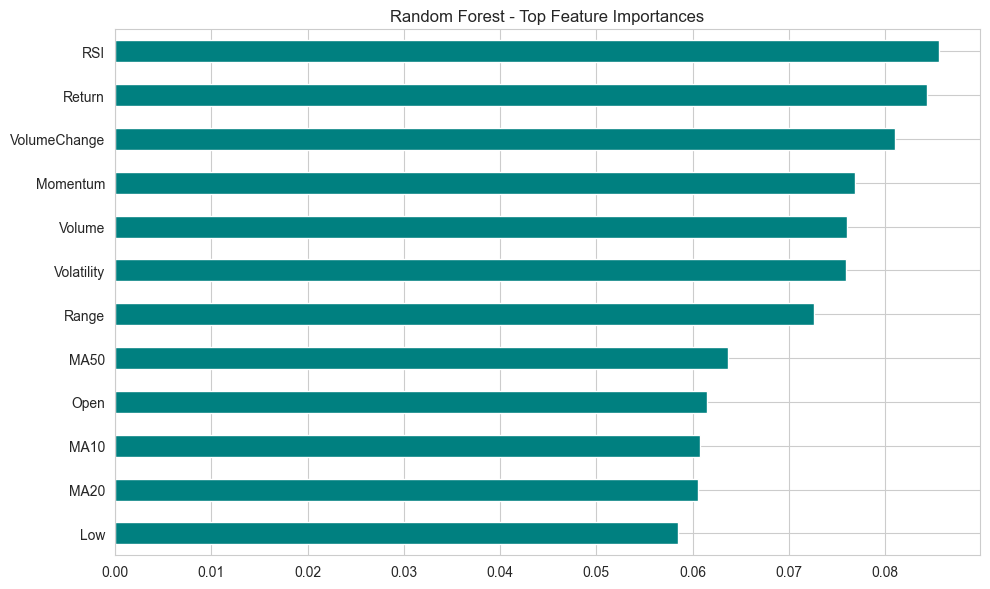

Random Forest trained
              precision    recall  f1-score   support

           0       0.47      0.41      0.44      1840
           1       0.54      0.60      0.57      2110

    accuracy                           0.51      3950
   macro avg       0.51      0.51      0.50      3950
weighted avg       0.51      0.51      0.51      3950



In [16]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, pred_rf),
    'Precision': precision_score(y_test, pred_rf),
    'Recall': recall_score(y_test, pred_rf),
    'F1 Score': f1_score(y_test, pred_rf)
})

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(12).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Random Forest - Top Feature Importances')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '06_feature_importance.png'), dpi=120)
plt.show()

print('Random Forest trained')
print(classification_report(y_test, pred_rf))

## Step 13: Model 3 - Convolutional Neural Network (Deep Learning)


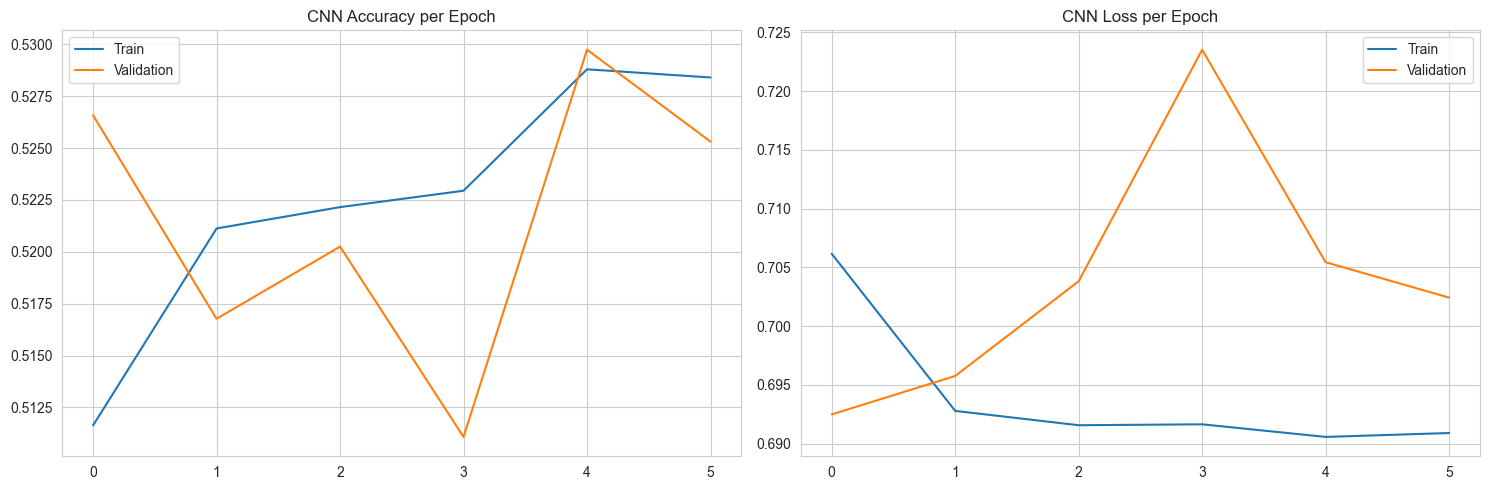

CNN trained
              precision    recall  f1-score   support

           0       0.46      0.13      0.20      1840
           1       0.53      0.87      0.66      2110

    accuracy                           0.52      3950
   macro avg       0.50      0.50      0.43      3950
weighted avg       0.50      0.52      0.45      3950



In [17]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn = models.Sequential([
    layers.Input(shape=(X_train.shape[1], 1)),
    layers.Conv1D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv1D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history = cnn.fit(X_train_cnn, y_train, validation_split=0.2,
                  epochs=30, batch_size=64, verbose=0, callbacks=[early])

prob_cnn = cnn.predict(X_test_cnn, verbose=0).ravel()
pred_cnn = (prob_cnn > 0.5).astype(int)

results.append({
    'Model': 'CNN (Deep Learning)',
    'Accuracy': accuracy_score(y_test, pred_cnn),
    'Precision': precision_score(y_test, pred_cnn),
    'Recall': recall_score(y_test, pred_cnn),
    'F1 Score': f1_score(y_test, pred_cnn)
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN Accuracy per Epoch'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('CNN Loss per Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '08_cnn_training.png'), dpi=120)
plt.show()

print('CNN trained')
print(classification_report(y_test, pred_cnn))

## Step 14: Model Comparison


Model Comparison Table


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.5273,0.5334,0.9190,0.6750
Random Forest,0.5122,0.5389,0.6009,0.5682
CNN (Deep Learning),0.5233,0.5330,0.8697,0.6609


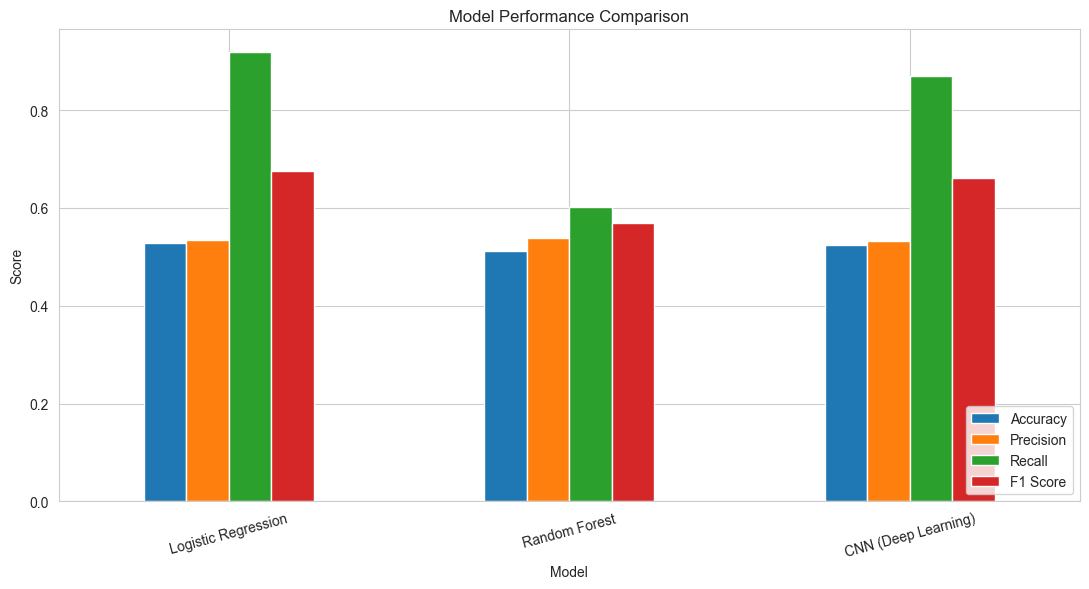

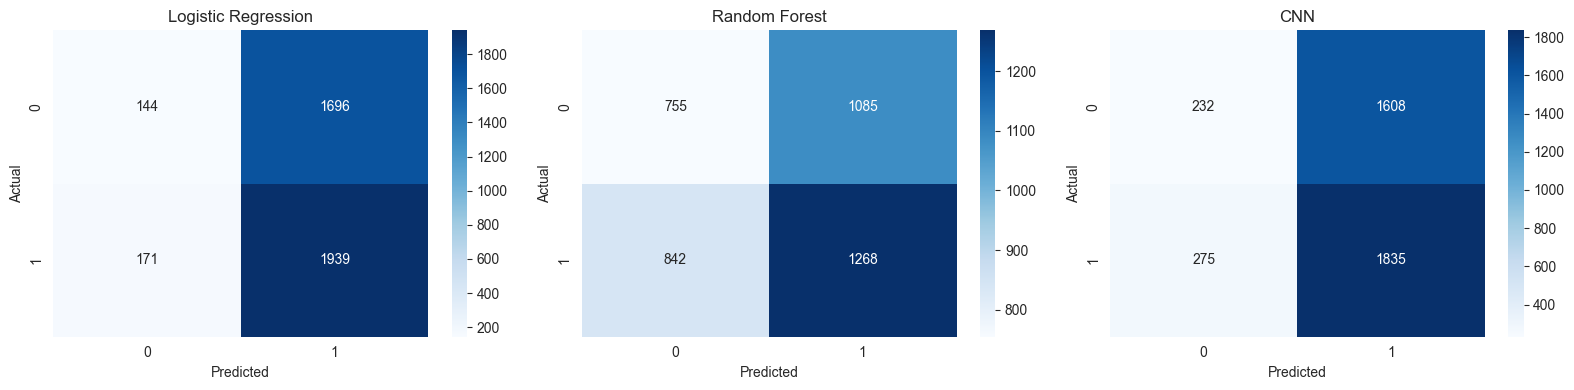

In [18]:
comparison = pd.DataFrame(results).set_index('Model').round(4)
comparison.to_csv('model_comparison.csv')
print('Model Comparison Table')
display(comparison)

comparison.plot(kind='bar', figsize=(11, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score'); plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '09_model_comparison.png'), dpi=120)
plt.show()

preds = {'Logistic Regression': pred_lr, 'Random Forest': pred_rf, 'CNN': pred_cnn}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, p) in zip(axes, preds.items()):
    sns.heatmap(confusion_matrix(y_test, p), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '10_confusion_matrices.png'), dpi=120)
plt.show()

## Step 15: Predicting Future Closing Price (CNN Regression)



Future Price Prediction Performance for AAPL
RMSE: 7.19
MAE : 5.81
R2  : 0.9597


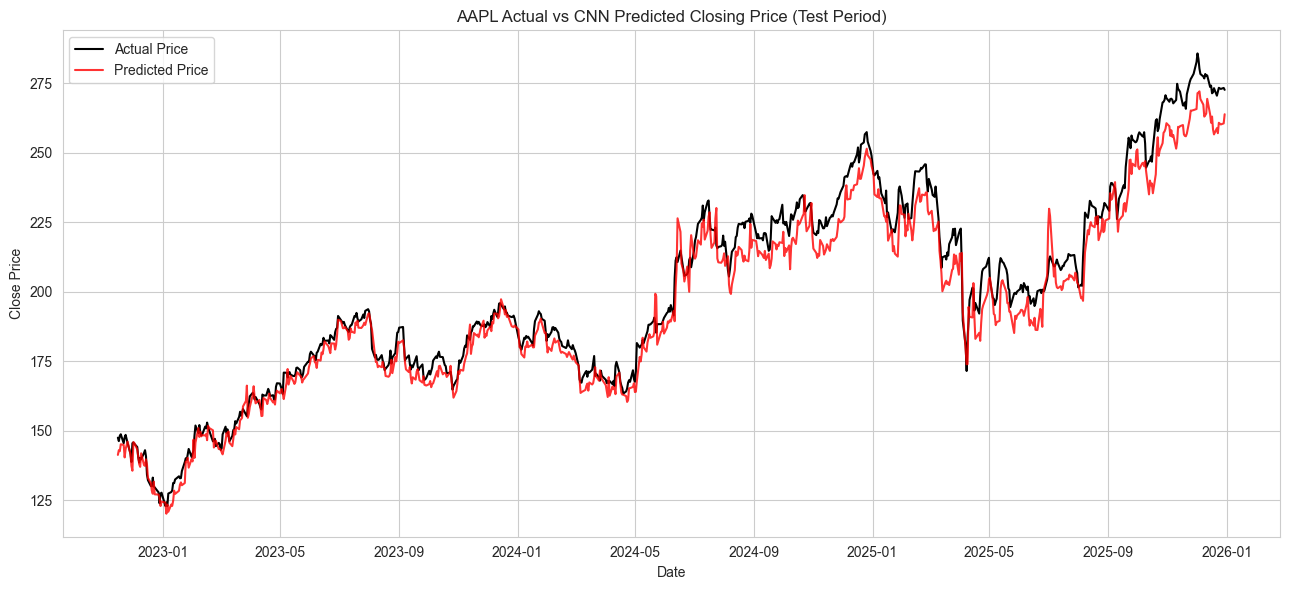

In [19]:
seq_data = df[df['Ticker'] == 'AAPL'].sort_values('Date').reset_index(drop=True)
seq_features = ['Close', 'Volume', 'Return', 'MA10', 'MA20', 'RSI', 'Volatility']
window = 60

closes = seq_data['Close'].values
returns = seq_data['Return'].values

n_samples = len(seq_data) - 1 - window
split_sample = int(n_samples * 0.8)
train_rows = window + split_sample

feat_scaler = StandardScaler()
feat_scaler.fit(seq_data[seq_features].iloc[:train_rows])
scaled_feats = feat_scaler.transform(seq_data[seq_features])

Xs, y_ret, anchor, dates = [], [], [], []
for i in range(window, len(seq_data) - 1):
    Xs.append(scaled_feats[i - window:i])
    y_ret.append(returns[i + 1])
    anchor.append(closes[i])
    dates.append(seq_data['Date'].iloc[i + 1])
Xs = np.array(Xs); y_ret = np.array(y_ret)
anchor = np.array(anchor); dates = np.array(dates)

Xtr, Xte = Xs[:split_sample], Xs[split_sample:]
ytr, yte = y_ret[:split_sample], y_ret[split_sample:]
anchor_te = anchor[split_sample:]
dates_te = dates[split_sample:]

reg = models.Sequential([
    layers.Input(shape=(window, len(seq_features))),
    layers.Conv1D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(32, 3, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
reg.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_r = callbacks.EarlyStopping(patience=6, restore_best_weights=True)
reg.fit(Xtr, ytr, validation_split=0.2, epochs=40, batch_size=32,
        verbose=0, callbacks=[early_r])

pred_ret = reg.predict(Xte, verbose=0).ravel()
pred_price = anchor_te * (1 + pred_ret)
true_price = anchor_te * (1 + yte)

rmse = np.sqrt(mean_squared_error(true_price, pred_price))
mae = mean_absolute_error(true_price, pred_price)
r2 = r2_score(true_price, pred_price)

print('Future Price Prediction Performance for AAPL')
print('RMSE:', round(rmse, 2))
print('MAE :', round(mae, 2))
print('R2  :', round(r2, 4))

plt.figure(figsize=(13, 6))
plt.plot(dates_te, true_price, label='Actual Price', color='black')
plt.plot(dates_te, pred_price, label='Predicted Price', color='red', alpha=0.8)
plt.title('AAPL Actual vs CNN Predicted Closing Price (Test Period)')
plt.xlabel('Date'); plt.ylabel('Close Price'); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '11_future_price_prediction.png'), dpi=120)
plt.show()

## Step 16: Entry and Exit Signal Demo



In [20]:
test_df = df.iloc[split_index:].copy()
test_df['Prediction'] = pred_rf
aapl_signals = test_df[test_df['Ticker'] == 'AAPL'].copy()
aapl_signals['Signal'] = np.where(aapl_signals['Prediction'] == 1, 'BUY', 'SELL')

demo = aapl_signals[['Date', 'Close', 'Signal']].tail(10).reset_index(drop=True)
print('Recent Entry / Exit Signals for AAPL')
display(demo)

Recent Entry / Exit Signals for AAPL


,Date,Close,Signal
0,2025-12-16,274.100739,BUY
1,2025-12-17,271.335876,BUY
2,2025-12-18,271.685242,BUY
3,2025-12-19,273.162506,BUY
4,2025-12-22,270.467499,BUY
5,2025-12-23,271.854919,SELL
6,2025-12-24,273.302216,SELL
7,2025-12-26,272.892975,BUY
8,2025-12-29,273.252350,BUY
9,2025-12-30,272.573578,BUY


In [21]:
df.to_csv('stock_data_cleaned.csv', index=False)
print('Cleaned dataset saved as stock_data_cleaned.csv')
print('Model comparison saved as model_comparison.csv')
print('All EDA images saved in the EDA_Visualizations folder')
print('\nFinal cleaned dataset shape:', df.shape)

Cleaned dataset saved as stock_data_cleaned.csv
Model comparison saved as model_comparison.csv
All EDA images saved in the EDA_Visualizations folder

Final cleaned dataset shape: (19748, 24)
